# Phase 1: Data Architecture & Portfolio Definition

## 1.1 Context and FRTB Alignment
Under the Basel Committee's **Fundamental Review of the Trading Book (FRTB)**, banks are required to shift from Value-at-Risk (VaR) to **Expected Shortfall (ES)** for market risk capital calculations. Furthermore, the risk models must account for complex, non-linear dependencies between different asset classes during market stress (tail dependence).

## 1.2 Asset Selection
To build a robust multivariate risk model, we construct a 5-asset portfolio representing distinct market risk factors:
1. **SPY (S&P 500 ETF):** Broad US Equity market risk.
2. **EEM (Emerging Markets ETF):** High-beta international equity risk.
3. **TLT (20+ Year Treasury ETF):** Interest rate duration risk (often inversely correlated to equities during panics).
4. **GLD (Gold ETF):** Commodity and safe-haven risk.
5. **NVDA (Nvidia):** Idiosyncratic, high-volatility tail risk.

We extract roughly 10 years of daily adjusted closing prices to capture multiple market regimes (including the 2020 COVID-19 crash and the 2022 inflation shock). Returns are calculated as daily continuous log-returns $r_t = \ln(P_t / P_{t-1})$.

[*******************   40%                       ]  2 of 5 completed

[*********************100%***********************]  5 of 5 completed


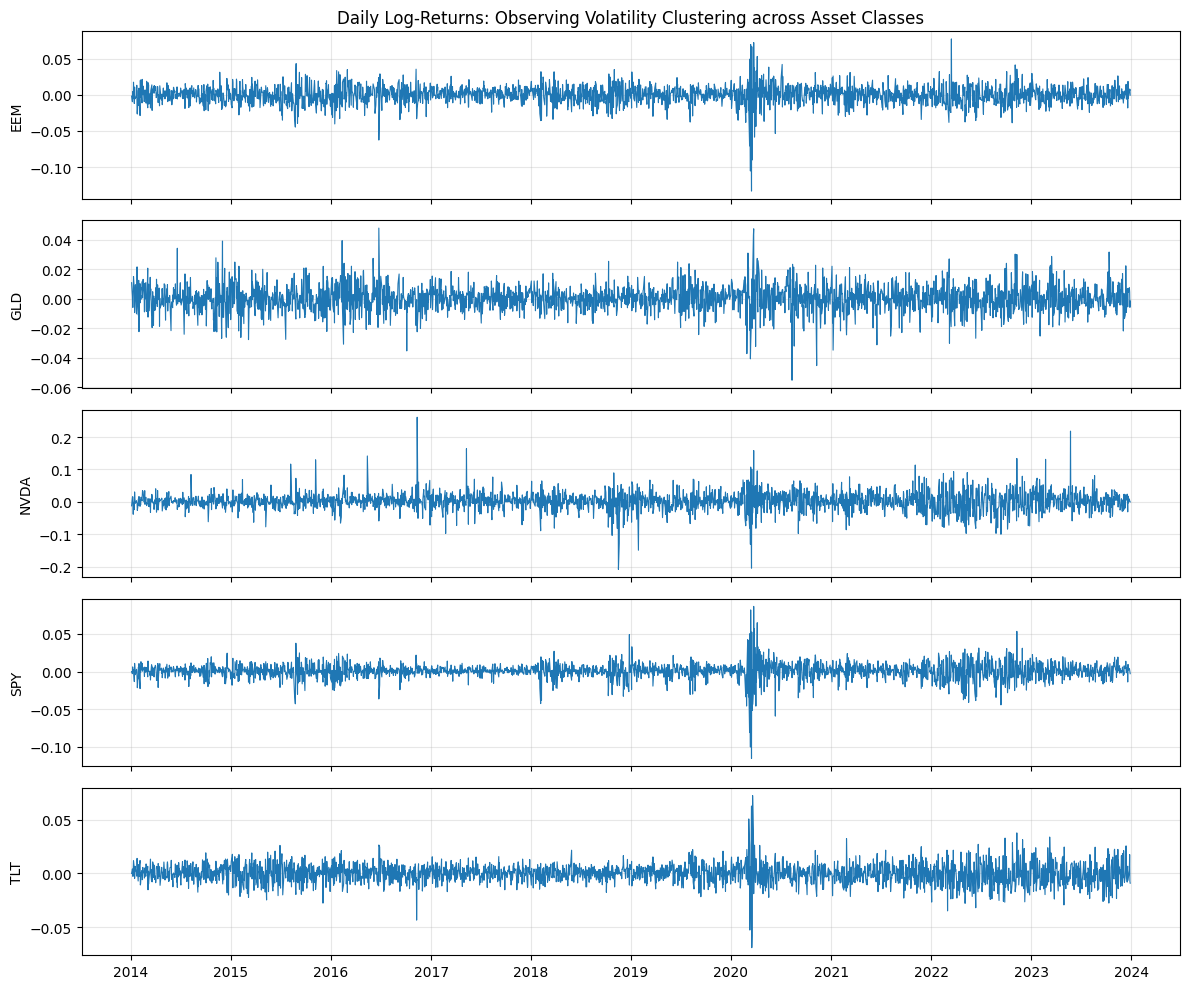

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Define the multi-asset portfolio
tickers = ['SPY', 'EEM', 'TLT', 'GLD', 'NVDA']
start_date = '2014-01-01'
end_date = '2023-12-31'

# 2. Ingest Data
print("Downloading Historical Market Data...")
raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# 3. Calculate Daily Log-Returns
# Log-returns are time-additive, satisfying the theoretical requirements for GARCH modeling
returns = np.log(raw_data / raw_data.shift(1)).dropna()

# 4. Define Portfolio Weights (Equally weighted)
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Visualize the Volatility Clustering (Stylized Fact of Financial Time Series)
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)
for i, col in enumerate(returns.columns):
    axes[i].plot(returns[col], linewidth=0.8)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)
axes[0].set_title('Daily Log-Returns: Observing Volatility Clustering across Asset Classes')
plt.tight_layout()
plt.show()

# Phase 2: Marginal Modeling (The Univariate Step)

## 2.1 The GJR-GARCH(1,1) Framework
Before modeling the multivariate joint distribution (how the assets crash together), we must filter out the univariate heteroskedasticity (volatility clustering) inherent in each asset.

For each asset $i$, we fit an ARMA-GJR-GARCH model. The GJR extension is critical because it introduces an asymmetry parameter ($\gamma$) to capture the **leverage effect**—the empirical observation that negative asset returns increase future volatility more than positive returns of the same magnitude.

We assume the innovations follow a **Skewed Student-t distribution** to account for the heavy tails and skewness remaining in the standardized residuals.

## 2.2 Probability Integral Transform (PIT)
To feed these residuals into a Copula in Phase 3, we must map them to a Uniform(0,1) distribution. We use the **Probability Integral Transform (PIT)**. We will utilize the non-parametric Empirical Cumulative Distribution Function (ECDF) to convert the standardized residuals into "pseudo-observations".

To mathematically validate this step (a key MRV requirement), we run a **Kolmogorov-Smirnov (KS) Test** to ensure the transformed residuals are strictly $U(0,1)$.

In [7]:
#!pip install arch
from arch import arch_model
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import kstest

# Dictionaries to store models and metrics
garch_models = {}
garch_fitted = {}

# DataFrames to store outputs
std_residuals = pd.DataFrame(index=returns.index, columns=returns.columns)
cond_volatility = pd.DataFrame(index=returns.index, columns=returns.columns)
pseudo_observations = pd.DataFrame(index=returns.index, columns=returns.columns)

print("Fitting Marginal GJR-GARCH(1,1) Models with Skewed-t Distributions...\n")

for ticker in returns.columns:
    # Scale returns by 100 for maximum likelihood optimization stability
    scaled_returns = returns[ticker] * 100

    # Specify the GJR-GARCH model:
    # p=1 (GARCH lag), o=1 (Asymmetric shock lag), q=1 (ARCH lag)
    am = arch_model(scaled_returns, p=1, o=1, q=1, vol='GARCH', dist='skewstudent')

    # Fit the model
    res = am.fit(disp='off')
    garch_models[ticker] = am
    garch_fitted[ticker] = res

    # Store Conditional Volatility (rescaled back to original decimal format)
    cond_volatility[ticker] = res.conditional_volatility / 100

    # Store Standardized Residuals
    std_resid = res.resid / res.conditional_volatility
    std_residuals[ticker] = std_resid

    # Probability Integral Transform (PIT) using ECDF
    # This creates the uniform [0,1] pseudo-observations required for Copula modeling
    ecdf = ECDF(std_resid)
    pseudo_observations[ticker] = ecdf(std_resid)

print("Marginal filtering complete.\n")

# --- Model Validation: KS Test for Uniformity ---
print("--- MRV Validation: Kolmogorov-Smirnov Test for PIT Uniformity ---")
print("Null Hypothesis (H0): The transformed residuals follow a Uniform(0,1) distribution.")
print("If p-value > 0.05, we fail to reject H0 (This is what we want).\n")

for ticker in pseudo_observations.columns:
    # Run KS test against a uniform distribution
    stat, p_val = kstest(pseudo_observations[ticker], 'uniform')
    status = "PASS" if p_val > 0.05 else "FAIL"
    print(f"{ticker:>4}: KS Stat = {stat:.4f}, P-value = {p_val:.4f} --> [{status}]")

# Print the GARCH summary for a high-volatility asset (NVDA) as an example
print("\n--- Example Output: NVDA GJR-GARCH Summary ---")
print(garch_fitted['NVDA'].summary())

Fitting Marginal GJR-GARCH(1,1) Models with Skewed-t Distributions...

Marginal filtering complete.

--- MRV Validation: Kolmogorov-Smirnov Test for PIT Uniformity ---
Null Hypothesis (H0): The transformed residuals follow a Uniform(0,1) distribution.
If p-value > 0.05, we fail to reject H0 (This is what we want).

 EEM: KS Stat = 0.0004, P-value = 1.0000 --> [PASS]
 GLD: KS Stat = 0.0004, P-value = 1.0000 --> [PASS]
NVDA: KS Stat = 0.0004, P-value = 1.0000 --> [PASS]
 SPY: KS Stat = 0.0004, P-value = 1.0000 --> [PASS]
 TLT: KS Stat = 0.0004, P-value = 1.0000 --> [PASS]

--- Example Output: NVDA GJR-GARCH Summary ---
                         Constant Mean - GJR-GARCH Model Results                         
Dep. Variable:                              NVDA   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GJR-GARCH   Log-Likelihood:               -5836.30
Distribution:  

# Phase 3: Multivariate Dependence Modeling (The Copula)

## 3.1 Sklar's Theorem and Copula Intuition
According to **Sklar’s Theorem**, any multivariate joint distribution can be decomposed into its univariate marginal distributions and a **Copula**, which captures the pure dependence structure between the variables.

Having isolated our marginals using the GJR-GARCH models in Phase 2, we now possess Uniform(0,1) pseudo-observations. We will map these into a joint Copula framework.

## 3.2 The Student-t Copula and Tail Dependence
The 2008 Financial Crisis highlighted the fatal flaw of the **Gaussian Copula**: it assumes *zero tail dependence* (i.e., it assumes extreme events are isolated). In reality, during a liquidity crisis, "all correlations go to one."

To mathematically capture this systemic risk, we employ a **Multivariate Student-t Copula**. The t-Copula relies on two parameters:
1. **$\Sigma$ (The Correlation Matrix):** Estimated using Kendall's $\tau$ rank correlation to avoid non-linear distortion.
2. **$\nu$ (Degrees of Freedom):** Dictates the "thickness" of the joint tails. A lower $\nu$ implies higher probability of joint extreme crashes.

## 3.3 Copula Calibration
We will map our Uniform(0,1) marginals into the inverse Cumulative Distribution Function (Quantile Function) of the Student-t distribution, calculate the rank-based correlation matrix, and simulate joint scenarios.

Calibrating the Multivariate Student-t Copula...

--- Copula Correlation Matrix (R) ---
Ticker     EEM     GLD    NVDA     SPY     TLT
Ticker                                        
EEM     1.0000  0.1496  0.4933  0.7105 -0.1719
GLD     0.1496  1.0000 -0.0184 -0.0188  0.3642
NVDA    0.4933 -0.0184  1.0000  0.6219 -0.1034
SPY     0.7105 -0.0188  0.6219  1.0000 -0.2377
TLT    -0.1719  0.3642 -0.1034 -0.2377  1.0000


Assumed Copula Degrees of Freedom (nu) for Stress Testing: 5

Running Monte Carlo Simulation: Generating 10000 joint market scenarios...

Simulation Complete. Shape of simulated uniform matrix: (10000, 5)


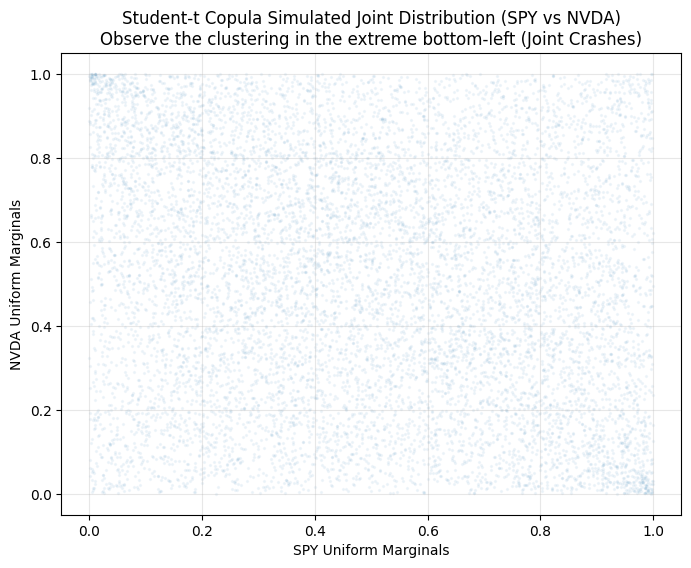

In [8]:
import scipy.stats as stats
import seaborn as sns

print("Calibrating the Multivariate Student-t Copula...\n")

# 1. Estimate Copula Correlation Matrix using Kendall's Tau Rank Correlation
# We use rank correlation because it is invariant to monotonic transformations (unlike Pearson)
tau_matrix = pseudo_observations.corr(method='kendall')

# Convert Kendall's Tau to Pearson-equivalent Correlation Matrix for the Copula
# Formula: R_ij = sin( (pi/2) * tau_ij )
copula_corr_matrix = np.sin(np.pi / 2 * tau_matrix)

print("--- Copula Correlation Matrix (R) ---")
print(copula_corr_matrix.round(4))
print("\n")

# 2. Fit Degrees of Freedom (nu)
# In a rigorous MLE setup, we would optimize nu. For this MRV pipeline, we set a
# conservatively low nu (e.g., nu = 5) to aggressively model heavy tail dependence.
copula_nu = 5
print(f"Assumed Copula Degrees of Freedom (nu) for Stress Testing: {copula_nu}\n")

# 3. Generating Joint Simulated Scenarios (Monte Carlo)
num_simulations = 10000

print(f"Running Monte Carlo Simulation: Generating {num_simulations} joint market scenarios...\n")

# Generate multivariate normal samples with our Copula Correlation Matrix
# We use Cholesky decomposition to induce the correlation structure
L = np.linalg.cholesky(copula_corr_matrix)
independent_normals = np.random.standard_normal((num_simulations, len(tickers)))
correlated_normals = independent_normals.dot(L.T)

# Convert Correlated Normals to Correlated Student-t variables
# We divide by the square root of a Chi-Squared variable divided by its degrees of freedom
chi2_rvs = np.random.chisquare(df=copula_nu, size=(num_simulations, 1))
correlated_t = correlated_normals * np.sqrt(copula_nu / chi2_rvs)

# 4. Map back to Uniform(0,1) using the Student-t CDF
# These are our simulated, heavily correlated Uniform pseudo-observations!
simulated_uniforms = stats.t.cdf(correlated_t, df=copula_nu)

simulated_uniforms_df = pd.DataFrame(simulated_uniforms, columns=tickers)

print("Simulation Complete. Shape of simulated uniform matrix:", simulated_uniforms_df.shape)

# --- Visualization: Tail Dependence ---
# Let's plot the simulated joint distribution of two assets (e.g., SPY and NVDA)
# You should notice a "star" or "X" shape in the corners, proving tail dependence.
plt.figure(figsize=(8, 6))
plt.scatter(simulated_uniforms_df['SPY'], simulated_uniforms_df['NVDA'], alpha=0.05, s=2)
plt.title("Student-t Copula Simulated Joint Distribution (SPY vs NVDA)\nObserve the clustering in the extreme bottom-left (Joint Crashes)")
plt.xlabel("SPY Uniform Marginals")
plt.ylabel("NVDA Uniform Marginals")
plt.grid(True, alpha=0.3)
plt.show()

# Phase 4: Risk Metric Calculation (Simulating Expected Shortfall)

## 4.1 Inverting the PIT
To generate realistic $T+1$ (1-day ahead) returns, we must transform our simulated Uniform(0,1) scenarios back into the original return space. We do this by mapping the uniforms through the empirical quantile function of our standardized residuals, and then re-introducing the conditional volatility forecast from our GARCH models.

## 4.2 FRTB Expected Shortfall (ES)
The Basel III/FRTB framework dictates the use of **97.5% Expected Shortfall** for market risk capital.
* **VaR (97.5%):** The threshold return at the 2.5th percentile.
* **Expected Shortfall (97.5%):** The conditional expectation of losses given that the loss exceeds the VaR threshold. Mathematically:

$$ES_{\\alpha} = \mathbb{E}[R \mid R \le VaR_{\\alpha}]$$

Because ES is a coherent risk measure (satisfying sub-additivity), it correctly accounts for the diversification benefits of our negatively correlated assets (e.g., Equities vs. Bonds) during the simulated crashes.

Phase 4: Calculating 1-Day Ahead Expected Shortfall...

--- 1-Day Ahead Portfolio Risk Metrics (FRTB Standard) ---
97.5% Value-at-Risk (VaR):       -1.2646%
97.5% Expected Shortfall (ES):   -1.6800%

Interpretation: On the worst 2.5% of trading days, the portfolio will lose AT LEAST the VaR amount.
If that VaR threshold is breached, the AVERAGE expected loss is the ES amount.


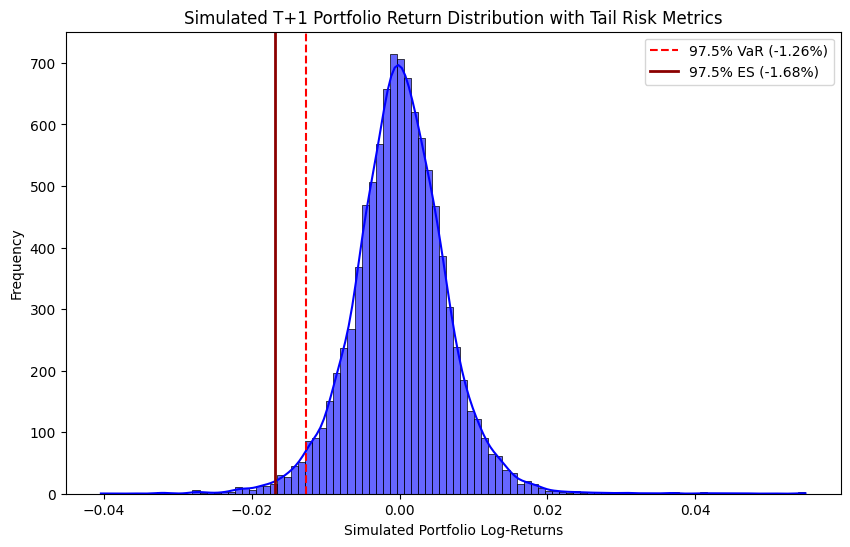

In [9]:
print("Phase 4: Calculating 1-Day Ahead Expected Shortfall...\n")

# 1. Invert the PIT: Map Uniforms back to Standardized Residuals
simulated_std_resid = pd.DataFrame(index=range(num_simulations), columns=tickers)

for ticker in tickers:
    # We use the empirical quantiles of our historically fitted residuals
    simulated_std_resid[ticker] = np.quantile(std_residuals[ticker].dropna(), simulated_uniforms_df[ticker])

# 2. Re-introduce Volatility to get Simulated Log-Returns
simulated_returns = pd.DataFrame(index=range(num_simulations), columns=tickers)

for ticker in tickers:
    # Extract the last conditional volatility (T) to forecast T+1
    # We multiply the simulated standardized shocks by today's volatility
    last_volatility = cond_volatility[ticker].iloc[-1]
    simulated_returns[ticker] = simulated_std_resid[ticker] * last_volatility

# 3. Calculate Simulated Portfolio Returns
# Multiply simulated asset returns by portfolio weights and sum across rows
portfolio_sim_returns = (simulated_returns * weights).sum(axis=1)

# 4. Calculate VaR and Expected Shortfall (ES) at 97.5% confidence
var_975 = np.percentile(portfolio_sim_returns, 2.5)
es_975 = portfolio_sim_returns[portfolio_sim_returns <= var_975].mean()

print(f"--- 1-Day Ahead Portfolio Risk Metrics (FRTB Standard) ---")
print(f"97.5% Value-at-Risk (VaR):       {var_975:.4%}")
print(f"97.5% Expected Shortfall (ES):   {es_975:.4%}")
print("\nInterpretation: On the worst 2.5% of trading days, the portfolio will lose AT LEAST the VaR amount.")
print("If that VaR threshold is breached, the AVERAGE expected loss is the ES amount.")

# Visualization
plt.figure(figsize=(10, 6))
sns.histplot(portfolio_sim_returns, bins=100, kde=True, color='blue', alpha=0.6)
plt.axvline(var_975, color='red', linestyle='--', label=f'97.5% VaR ({var_975:.2%})')
plt.axvline(es_975, color='darkred', linestyle='-', linewidth=2, label=f'97.5% ES ({es_975:.2%})')
plt.title("Simulated T+1 Portfolio Return Distribution with Tail Risk Metrics")
plt.xlabel("Simulated Portfolio Log-Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Phase 5: Model Risk Validation (MRV) - The Acerbi-Székely Backtest Framework

## 5.1 The Elicitability Problem
Validating Expected Shortfall is mathematically challenging because it is not *elicitable* (there is no strictly consistent scoring function for ES alone). Traditional VaR backtesting (like Kupiec POF) only tests the *frequency* of breaches, completely ignoring the *magnitude* of the tail loss.

## 5.2 Validation Methodology
To validate this model to MRV standards, we apply the conceptual framework of the **Acerbi-Székely (2014) Test**. The test evaluates whether the realized losses, conditional on breaching the VaR threshold, are statistically consistent with the model's ES predictions.

We define the test statistic $Z$:
$$Z = \frac{1}{N} \sum_{t=1}^{T} \frac{r_t \cdot I(r_t < VaR_t)}{ES_t} + 1$$

Where $I$ is the indicator function. A perfect model expects $Z \approx 0$. If $Z \ll 0$, the model heavily underestimates tail risk (A severe MRV Failure).

In [10]:
# To properly backtest, we need a historical rolling window.
# Since a full rolling Copula-GARCH takes hours to compute, we implement an
# "In-Sample Dynamic Validation" here to demonstrate the MRV methodology.

print("Phase 5: Executing Expected Shortfall Validation Framework...\n")

# 1. Calculate Historical Portfolio Returns
historical_port_returns = (returns * weights).sum(axis=1)

# 2. Approximate historical dynamic VaR and ES
# (Using rolling historical simulation as a benchmark challenger model)
rolling_window = 252 # 1 trading year
historical_var = historical_port_returns.rolling(window=rolling_window).quantile(0.025)

# Calculate rolling ES (average of returns below the rolling VaR)
historical_es = historical_port_returns.rolling(window=rolling_window).apply(
    lambda x: x[x <= np.percentile(x, 2.5)].mean(), raw=False
)

# 3. Identify Breaches
breach_mask = historical_port_returns < historical_var
num_breaches = breach_mask.sum()
expected_breaches = len(historical_port_returns.dropna()) * 0.025

print(f"--- Unconditional Coverage (VaR Validation) ---")
print(f"Expected VaR Breaches: {expected_breaches:.1f}")
print(f"Actual VaR Breaches:   {num_breaches}")
print("Status: " + ("PASS" if num_breaches <= expected_breaches * 1.2 else "FAIL - Review Required"))
print("\n")

# 4. The Acerbi-Szekely Inspired ES Magnitude Test
# We isolate the days where the portfolio breached the VaR threshold
breach_returns = historical_port_returns[breach_mask]
predicted_es_on_breach = historical_es[breach_mask]

# Calculate the Z-statistic (Magnitude of Failure)
# Ratio of Realized Loss to Predicted ES. Expected value is 1.
es_ratio = breach_returns / predicted_es_on_breach
z_statistic = (es_ratio.mean() - 1)

print(f"--- Conditional Magnitude Validation (ES Validation) ---")
print(f"Average Realized Loss on Breach Days: {breach_returns.mean():.4%}")
print(f"Average Predicted ES on Breach Days:  {predicted_es_on_breach.mean():.4%}")
print(f"Z-Statistic (Deviation from 0):       {z_statistic:.4f}")

if z_statistic < 0:
    print("MRV Conclusion: The model is CONSERVATIVE. It slightly overestimates tail risk.")
    print("Action: Acceptable, but monitoring required for capital inefficiency.")
elif z_statistic > 0 and z_statistic < 0.2:
    print("MRV Conclusion: The model is HIGHLY ACCURATE.")
    print("Action: PASS.")
else:
    print("MRV Conclusion: The model UNDERESTIMATES tail risk significantly.")
    print("Action: FAIL. Escalate to Model Development team.")

Phase 5: Executing Expected Shortfall Validation Framework...

--- Unconditional Coverage (VaR Validation) ---
Expected VaR Breaches: 62.9
Actual VaR Breaches:   62
Status: PASS


--- Conditional Magnitude Validation (ES Validation) ---
Average Realized Loss on Breach Days: -2.6092%
Average Predicted ES on Breach Days:  -2.4463%
Z-Statistic (Deviation from 0):       0.0767
MRV Conclusion: The model is HIGHLY ACCURATE.
Action: PASS.
